In [352]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.figsize']=(8,6)
import seaborn as sns
from sklearn.preprocessing import LabelEncoder 

In [353]:
df = pd.read_csv('banking_data.csv')
df.head()

,age,job,marital,marital_status,education,default,balance,housing,loan,contact,day,month,day_month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,married,tertiary,no,2143,yes,no,unknown,5,may,5-May,261,1,-1,0,unknown,no
1,44,technician,single,single,secondary,no,29,yes,no,unknown,5,may,5-May,151,1,-1,0,unknown,no
2,33,entrepreneur,married,married,secondary,no,2,yes,yes,unknown,5,may,5-May,76,1,-1,0,unknown,no
3,47,blue-collar,married,married,unknown,no,1506,yes,no,unknown,5,may,5-May,92,1,-1,0,unknown,no
4,33,unknown,single,single,unknown,no,1,no,no,unknown,5,may,5-May,198,1,-1,0,unknown,no


In [354]:
df.isnull().sum()

age               0
job               0
marital           3
marital_status    3
education         3
default           0
balance           0
housing           0
loan              0
contact           0
day               0
month             0
day_month         0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
y                 0
dtype: int64

In [355]:
# Dropping Null Values (Very less null values as compared to total data points)
df=df.dropna()

In [356]:
def plot_distribution(column, bins, labels, title, xlabel, figsize=(10,6)):
    plt.figure(figsize=figsize)
    plt.hist(df[column], bins=bins, color='steelblue', edgecolor='white',rwidth=0.5)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Count')
    midpoints = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins)-1)]
    plt.xticks(midpoints, labels)
    plt.tight_layout()
    plt.show()

## Age Distribution

In [357]:
df['age'].describe()

count    45210.000000
mean        40.938465
std         10.619311
min         18.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64

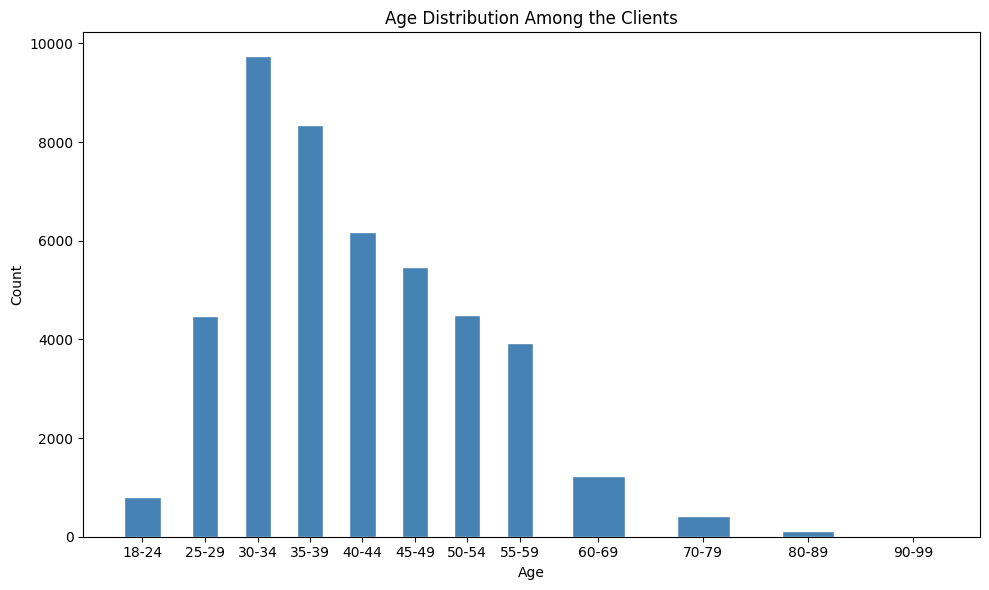

In [358]:
plot_distribution(column ='age',
                  bins= [18,25,30,35,40,45,50,55,60,70,80,90,100],
                labels= ['18-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59','60-69','70-79','80-89','90-99'],
                title='Age Distribution Among the Clients',
                xlabel='Age'
                )


In [359]:
# Most of our clients are between the age of 30 to 34 
# Peak at around 32.
# Our bank has comparatively less number of customers beyond age 60.

## Job Type Distribution among Clients

In [360]:
df['job'].value_counts()

job
blue-collar      9731
management       9458
technician       7597
admin.           5171
services         4154
retired          2266
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           936
unknown           288
Name: count, dtype: int64

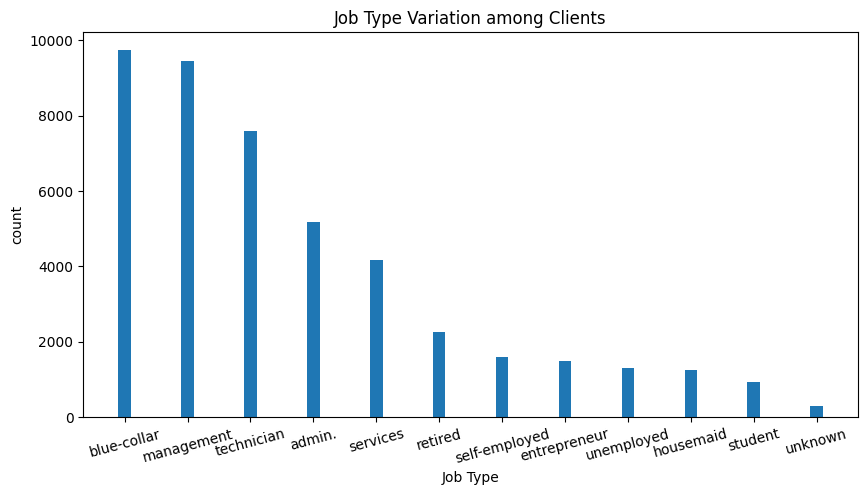

In [361]:
plt.figure(figsize=(10,5))
plt.bar(df['job'].value_counts().index,height=df['job'].value_counts().values,width=0.2)
plt.xticks(rotation=15)
plt.xlabel('Job Type')
plt.ylabel('count')
plt.title('Job Type Variation among Clients')
plt.show()

In [362]:
df['job'].value_counts()

job
blue-collar      9731
management       9458
technician       7597
admin.           5171
services         4154
retired          2266
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           936
unknown           288
Name: count, dtype: int64

## Marital Status Distribution

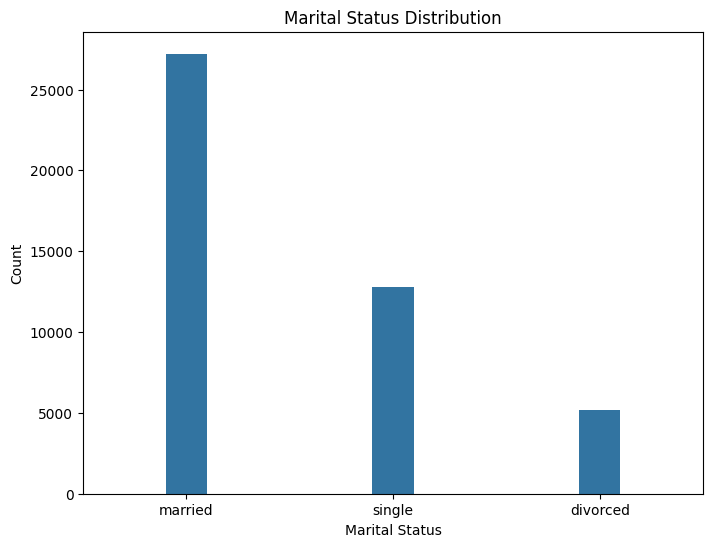

In [363]:
plt.figure(figsize=(8,6))
sns.countplot(x= df['marital_status'],width=0.2)
plt.title('Marital Status Distribution')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.show()

In [364]:
# Most of the customers of our Bank are married

## Level of Education among Clients 

In [365]:
df['education'].value_counts()
# 4 unique categories

education
secondary    23201
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

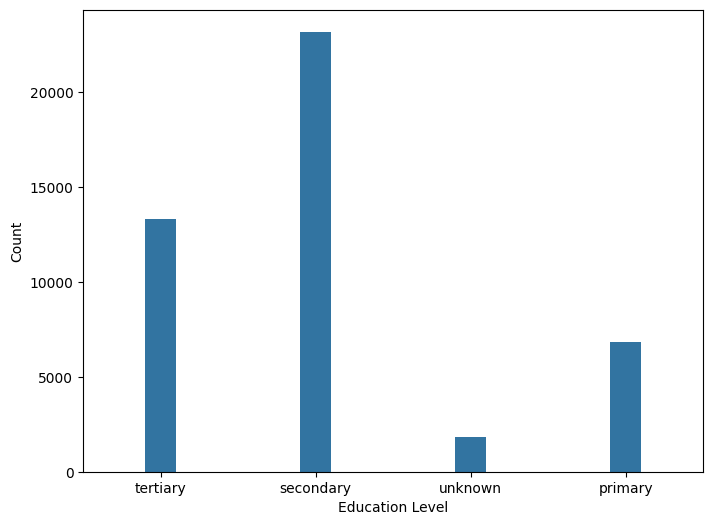

In [366]:
plt.figure(figsize=(8,6))
sns.countplot(x=df['education'],width=0.2)
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.show()

In [367]:
# Most of our client's education level is secondary

## Proportion of Clients that have credit in default

In [368]:
prop_of_cred_in_def= df[df['default']=='yes'].shape[0]/df.shape[0]
prop_of_cred_in_def 

0.018026985180269853

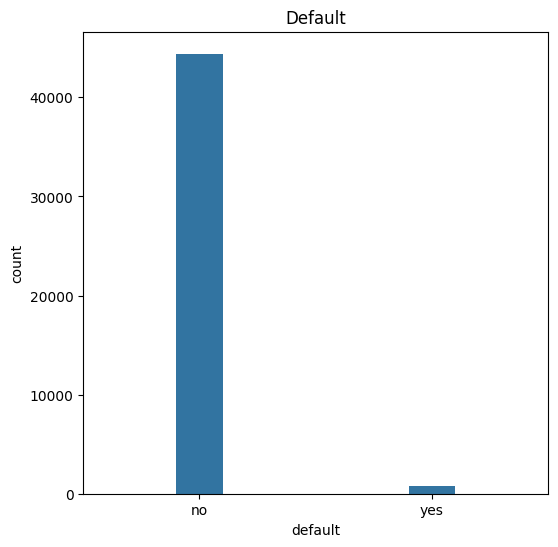

In [369]:
plt.figure(figsize=(6,6))
sns.countplot(x=df['default'],width=0.2)
plt.title('Default')
plt.show()

## Distribution of average yearly balance among the Clients

In [370]:
df['balance'].describe()

count     45210.000000
mean       1362.333024
std        3044.781647
min       -8019.000000
25%          72.000000
50%         448.500000
75%        1428.000000
max      102127.000000
Name: balance, dtype: float64

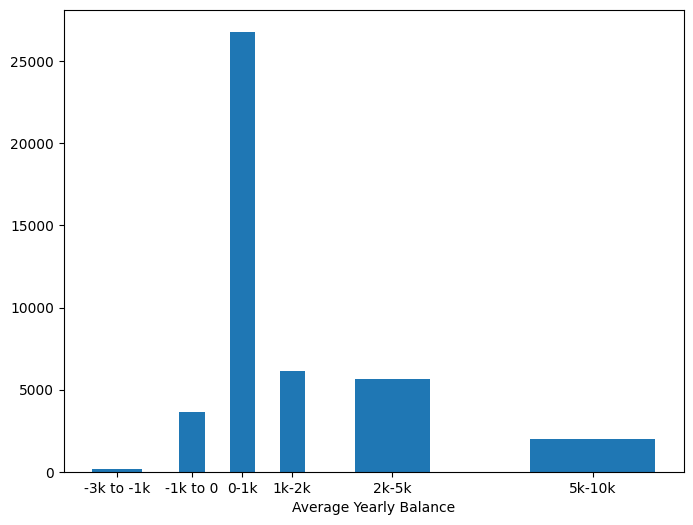

In [ ]:
plt.figure(figsize=(8,6))
plt.hist(df[df['balance']<=40000]['balance'],bins = [-3000,-1000,0,1000,2000,5000,10000],rwidth=0.5)
plt.xticks([-2000,-500,500,1500,3500,7500],['-3k to -1k','-1k to 0','0-1k','1k-2k','2k-5k','5k-10k'])
plt.xlabel('Average Yearly Balance')
plt.show()
# Ignoring Outliers since their data points are very very less

## Housing Loan

In [373]:
num_of_clients_with_housingn_loan =df[df['housing']=='yes'].shape[0]
num_of_clients_with_housingn_loan

25130

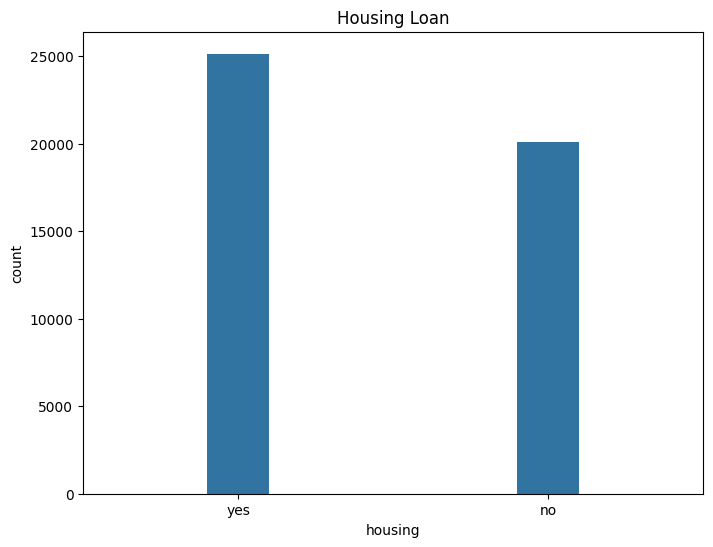

In [374]:
plt.figure(figsize=(8,6))
sns.countplot(x=df['housing'],width=0.2)
plt.title('Housing Loan')
plt.show()

## Personal Loan

In [375]:
num_of_clients_with_pers_loan=df[df['loan']=='yes'].shape[0]
num_of_clients_with_pers_loan

7244

## Communication Type

In [376]:
df['contact'].unique()

<StringArray>
['unknown', 'cellular', 'telephone']
Length: 3, dtype: str

In [377]:
df['contact'].value_counts()

contact
cellular     29288
unknown      13020
telephone     2902
Name: count, dtype: int64

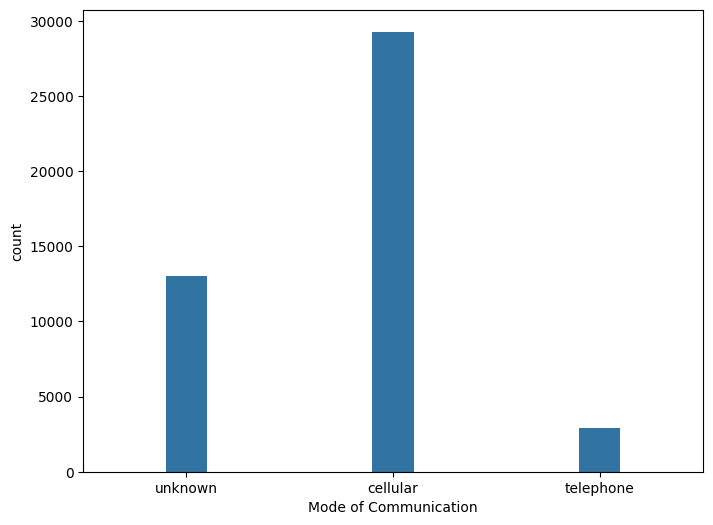

In [378]:
plt.figure(figsize=(8,6))
sns.countplot(x=df['contact'],width=0.2)
plt.xlabel('Mode of Communication')
plt.show()

In [379]:
# Mostly for our marketing campaign we used cellular mode of communication


## Distribution of last contact day of the month

In [380]:
df['day'].value_counts()

day
20    2752
18    2308
21    2025
17    1941
6     1932
5     1910
14    1848
8     1840
28    1830
7     1817
19    1757
29    1745
15    1703
12    1602
13    1585
30    1566
9     1561
11    1479
4     1445
16    1417
2     1293
27    1121
3     1079
26    1035
23     939
22     905
25     840
31     643
10     523
24     447
1      322
Name: count, dtype: int64

In [381]:
df['day'].unique()

array([ 5,  6,  7,  8,  9, 12, 13, 14, 15, 16, 19, 20, 21, 23, 26, 27, 28,
       29, 30,  2,  3,  4, 11, 17, 18, 24, 25,  1, 10, 22, 31])

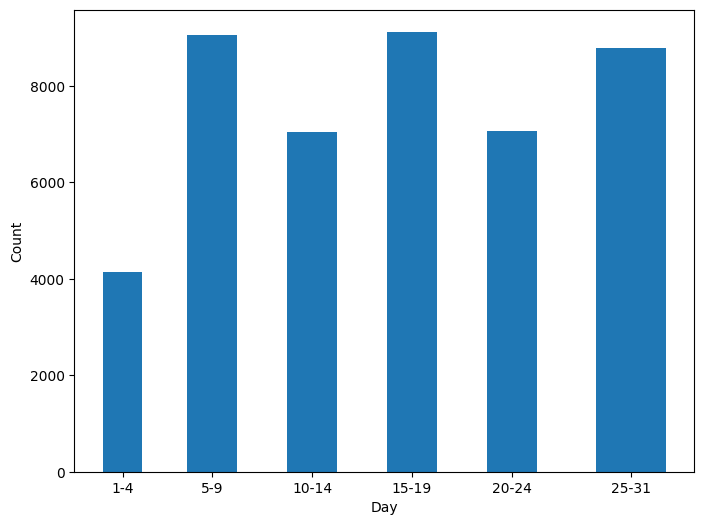

In [382]:
plt.hist(df['day'],bins=[1,5,10,15,20,25,32],rwidth=0.5)
plt.xticks([3,7.5,12.5,17.5,22.5,28.5],['1-4','5-9','10-14','15-19','20-24','25-31'])
plt.xlabel('Day')
plt.ylabel('Count')
plt.show()              

## Last Contact Month

In [383]:
df['month'].value_counts()

month
may    13766
jul     6895
aug     6247
jun     5341
nov     3972
apr     2932
feb     2649
jan     1403
oct      735
sep      579
mar      477
dec      214
Name: count, dtype: int64

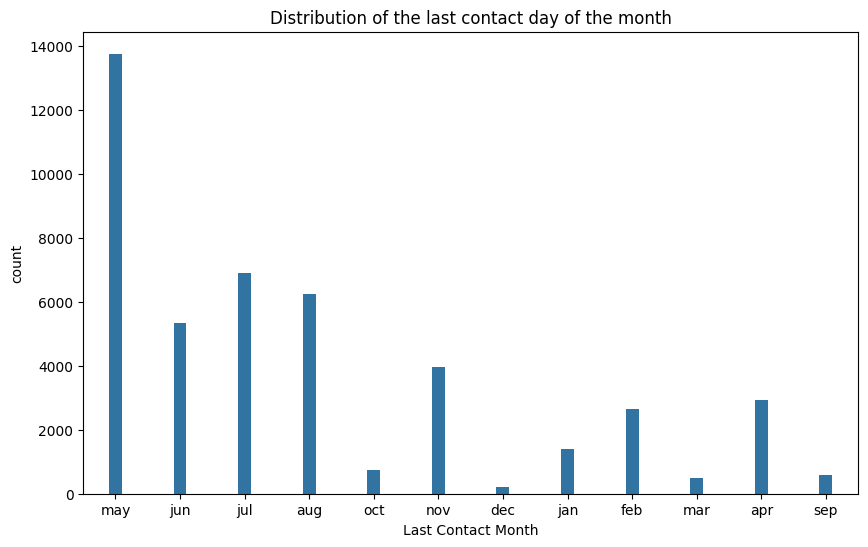

In [384]:
plt.figure(figsize=(10,6))
sns.countplot(x=df['month'],width=0.2)
plt.xlabel('Last Contact Month')
plt.ylabel('count')
plt.title('Distribution of the last contact day of the month')
plt.show()

In [385]:
# For most of our customers last contact month was may

## Duration of last contact

In [386]:
df['duration'].describe()

count    45210.000000
mean       258.155342
std        257.522333
min          0.000000
25%        103.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64

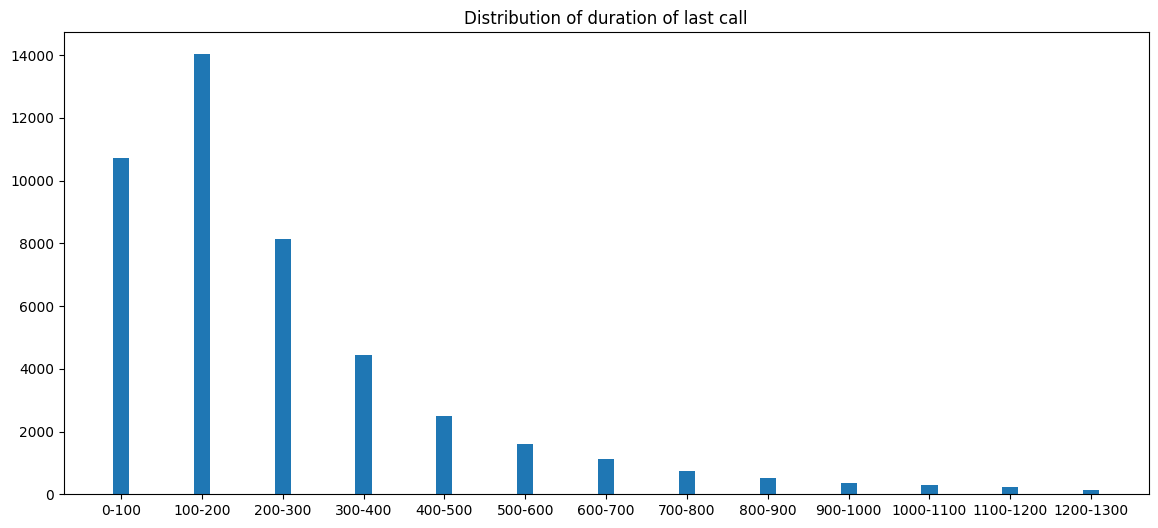

In [387]:
plt.figure(figsize=(14,6))
plt.hist(df['duration'],bins=[0,100,200,300,400,500,600,700,800,900,1000,1100,1200,1300],rwidth=0.2)
plt.xticks([50,150,250,350,450,550,650,750,850,950,1050,1150,1250],['0-100','100-200','200-300','300-400','400-500','500-600','600-700','700-800','800-900','900-1000','1000-1100','1100-1200','1200-1300'])
plt.title('Distribution of duration of last call')
plt.show()

## Number of contacts performed during the campaign 


In [388]:
df['campaign'].describe() 

count    45210.000000
mean         2.763791
std          3.098059
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         63.000000
Name: campaign, dtype: float64

In [389]:
df['campaign'].value_counts()

campaign
1     17545
2     12504
3      5521
4      3521
5      1764
6      1291
7       735
8       540
9       327
10      266
11      201
12      155
13      133
14       93
15       84
16       79
17       69
18       51
19       44
20       43
21       35
22       23
25       22
23       22
24       20
28       16
29       16
26       13
31       12
27       10
32        9
30        8
33        6
34        5
35        4
36        4
43        3
38        3
41        2
50        2
37        2
51        1
63        1
55        1
46        1
58        1
39        1
44        1
Name: count, dtype: int64

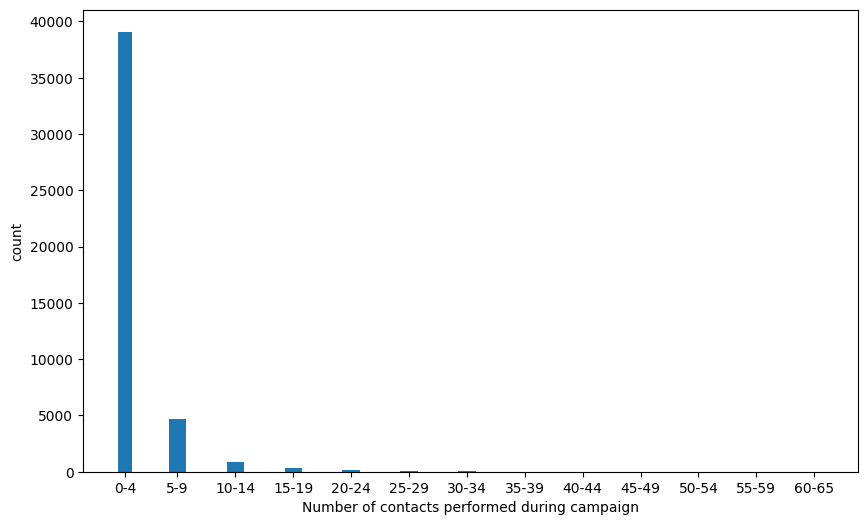

In [390]:
plt.figure(figsize=(10,6)) 
plt.hist(df['campaign'],bins=[1,5,10,15,20,25,30,35,40,45,50,55,60,65],rwidth=0.3)
plt.xticks([3,7.5,12.5,17.5,22.5,27.5,32.5,37.5,42.5,47.5,52.5,57.5,62.5],['0-4','5-9','10-14','15-19','20-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59','60-65'])
plt.xlabel('Number of contacts performed during campaign')
plt.ylabel('count')
plt.show()     

## Distribution of the number of days passed since the client was last contacted from a previous campaign

In [391]:
df['pdays'].value_counts()

pdays
-1      36954
 182      167
 92       147
 91       126
 183      126
        ...  
 541        1
 543        1
 871        1
 550        1
 530        1
Name: count, Length: 559, dtype: int64

In [392]:
# for pdays=-1, client was not contacted before
df[(df['pdays'] == -1)].shape[0]
#36954 clients were not contacted before

36954

In [393]:
df[~(df['pdays']==-1)]['pdays'].describe()

count    8256.000000
mean      224.545543
std       115.339156
min         1.000000
25%       133.000000
50%       194.000000
75%       327.000000
max       871.000000
Name: pdays, dtype: float64

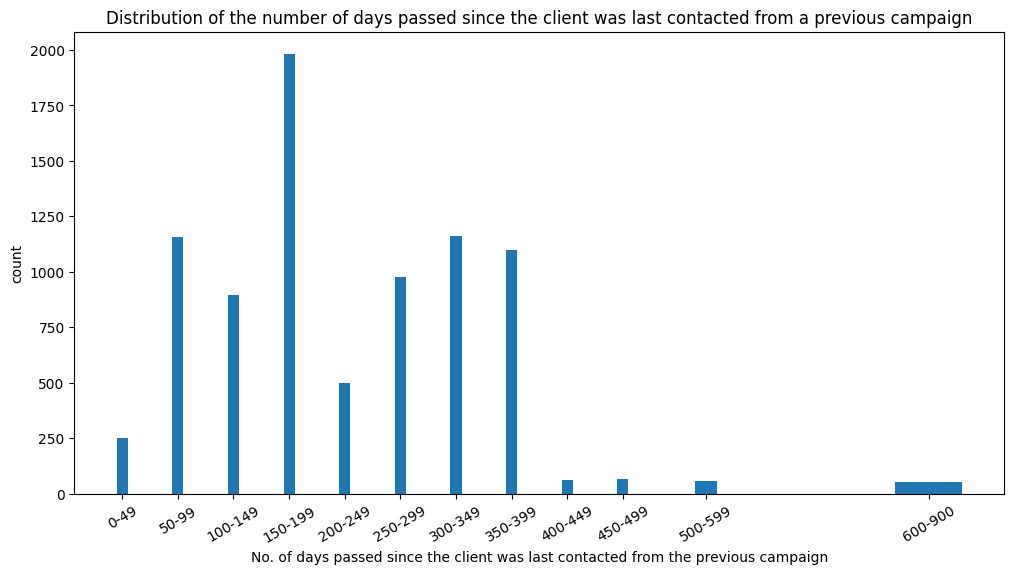

In [394]:
plt.figure(figsize=(12,6))
plt.hist(df[~(df['pdays']==-1)]['pdays'],bins=[0,50,100,150,200,250,300,350,400,450,500,600,900],rwidth=0.2)
plt.xticks([25,75,125,175,225,275,325,375,425,475,550,750],['0-49','50-99','100-149','150-199','200-249','250-299','300-349','350-399','400-449','450-499','500-599','600-900'],rotation=30)
plt.xlabel('No. of days passed since the client was last contacted from the previous campaign') 
plt.ylabel('count')
plt.title('Distribution of the number of days passed since the client was last contacted from a previous campaign')
plt.show()
# This distribution do not consider pdays=-1 i.e for those customers who were never contacted before

In [395]:
df[~(df['pdays']==-1)]['pdays'].describe()

count    8256.000000
mean      224.545543
std       115.339156
min         1.000000
25%       133.000000
50%       194.000000
75%       327.000000
max       871.000000
Name: pdays, dtype: float64

## Number of Contacts performed before the current campaign for each client

In [396]:
df['previous'].value_counts()

previous
0      36954
1       2772
2       2103
3       1142
4        714
5        459
6        278
7        205
8        130
9         92
10        67
11        65
12        44
13        38
15        20
14        19
17        15
16        13
19        11
20         8
23         8
18         6
22         6
27         5
24         5
21         4
25         4
29         4
30         3
26         2
37         2
38         2
28         2
51         1
275        1
58         1
32         1
40         1
55         1
35         1
41         1
Name: count, dtype: int64

In [397]:
df['previous'].describe()

count    45210.000000
mean         0.580513
std          2.303843
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        275.000000
Name: previous, dtype: float64

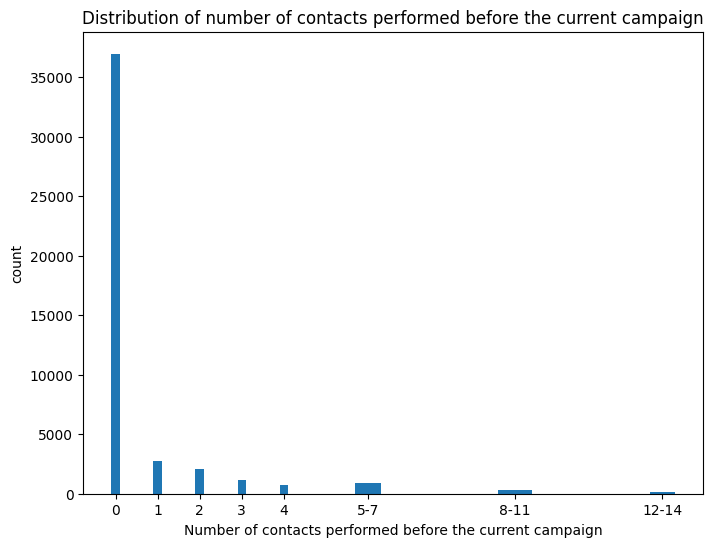

In [398]:
plt.figure(figsize=(8,6))
plt.hist(df['previous'],bins=[0,1,2,3,4,5,8,12,15],rwidth=0.2)
plt.xticks([0.5,1.5,2.5,3.5,4.5,6.5,10,13.5],['0','1','2','3','4','5-7','8-11','12-14'])
plt.title('Distribution of number of contacts performed before the current campaign')
plt.xlabel('Number of contacts performed before the current campaign')
plt.ylabel('count')
plt.show() 
# Ignoring Outliers since their data points are very very less 
              

## Outcomes of previous marketing campaign 

In [399]:
df['poutcome'].describe() 

count       45210
unique          4
top       unknown
freq        36959
Name: poutcome, dtype: object

In [400]:
df['poutcome'].value_counts()

poutcome
unknown    36959
failure     4900
other       1838
success     1513
Name: count, dtype: int64

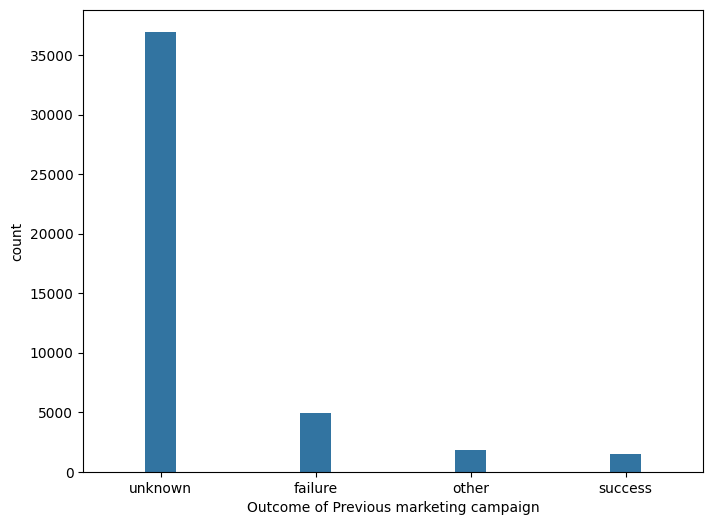

In [401]:
plt.figure(figsize=(8,6))
sns.countplot(x=df['poutcome'],width=0.2)
plt.xlabel('Outcome of Previous marketing campaign')
plt.ylabel('count')
plt.show()

## Distribution of clients who subscribed to a term deposit vs. those who did not

In [402]:
df['y'].describe()

count     45210
unique        2
top          no
freq      39917
Name: y, dtype: object

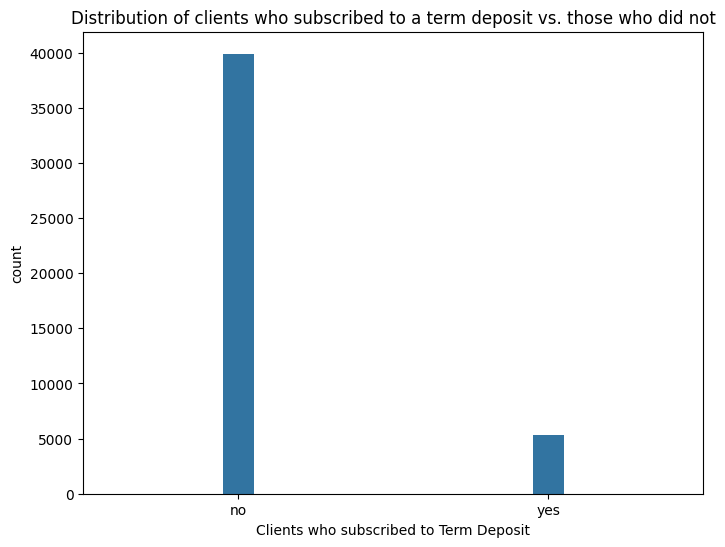

In [403]:
plt.figure(figsize=(8,6))
sns.countplot(x=df['y'],width=0.1)
plt.xlabel('Clients who subscribed to Term Deposit')
plt.ylabel('count') 
plt.title('Distribution of clients who subscribed to a term deposit vs. those who did not')
plt.show()

## Correlation between different attributes and the likelihood of subscribing to the term deposit

In [404]:
df=df.drop(['marital','contact','day','month','day_month','pdays','poutcome'],axis='columns')  ## Dropping these columns because whether client will subscribe or not does not dpeend on these columns except for marital column , i dropped marital column cause there was already one column named marital status which is same as marital
dummies= pd.get_dummies(df[['job','marital_status','education']],drop_first=True).astype(int) ## Converting text columns into numeric via dummies
df['default']=df['default'].replace({'no': 0, 'yes' :1})
df['housing']=df['housing'].replace({'no':0,'yes':1})
df['loan'] = df['loan'].replace({'no':0, 'yes':1})
df['y']=df['y'].replace({'no':0,'yes':1})

In [405]:
df.columns

Index(['age', 'job', 'marital_status', 'education', 'default', 'balance',
       'housing', 'loan', 'duration', 'campaign', 'previous', 'y'],
      dtype='str')

In [406]:
dummies

,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_status_married,marital_status_single,education_secondary,education_tertiary,education_unknown
0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0
1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0
2,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0
3,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45211,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0
45212,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0
45213,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0
45214,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0


In [407]:
df=pd.concat([df,dummies],axis='columns')
df=df.drop(['job','marital_status','education'],axis='columns')
df 

,age,default,balance,housing,loan,duration,campaign,previous,y,job_blue-collar,...,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_status_married,marital_status_single,education_secondary,education_tertiary,education_unknown
0,58,0,2143,1,0,261,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
1,44,0,29,1,0,151,1,0,0,0,...,0,0,1,0,0,0,1,1,0,0
2,33,0,2,1,1,76,1,0,0,0,...,0,0,0,0,0,1,0,1,0,0
3,47,0,1506,1,0,92,1,0,0,1,...,0,0,0,0,0,1,0,0,0,1
4,33,0,1,0,0,198,1,0,0,0,...,0,0,0,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45211,29,0,765,0,0,238,1,0,1,0,...,0,0,0,0,0,0,1,0,1,0
45212,68,0,1146,0,0,212,1,6,1,0,...,0,0,0,0,0,1,0,1,0,0
45213,53,0,583,0,0,226,1,4,1,0,...,0,0,0,0,0,1,0,0,1,0
45214,73,0,2850,0,0,300,1,8,1,0,...,0,0,0,0,0,1,0,1,0,0


In [408]:
corr= df.corr()
corr['y']
## Since there are many columns(73) it is not possible for us to plot heatmap so this is the correlation between different parameters and y

age                       0.025718
default                  -0.022450
balance                   0.052844
housing                  -0.139446
loan                     -0.068287
duration                  0.394472
campaign                 -0.073277
previous                  0.093628
y                         1.000000
job_blue-collar          -0.072191
job_entrepreneur         -0.019708
job_housemaid            -0.015237
job_management            0.032932
job_retired               0.079993
job_self-employed         0.000801
job_services             -0.027945
job_student               0.077024
job_technician           -0.009094
job_unemployed            0.020334
job_unknown               0.000244
marital_status_married   -0.060202
marital_status_single     0.063386
education_secondary      -0.036376
education_tertiary        0.066395
education_unknown         0.011991
Name: y, dtype: float64

In [409]:
corr
## Here duration of last call has highest positive correlation with whether customer will opt for term deposit or not

,age,default,balance,housing,loan,duration,campaign,previous,y,job_blue-collar,...,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_status_married,marital_status_single,education_secondary,education_tertiary,education_unknown
age,1.000000,-0.017907,0.097797,-0.185746,-0.015747,-0.004596,0.004648,0.001727,0.025718,-0.044195,...,-0.065845,-0.196904,-0.068724,0.000376,0.050181,0.286229,-0.427730,-0.094070,-0.081672,0.069618
default,-0.017907,1.000000,-0.066748,-0.006029,0.077233,-0.010018,0.016824,-0.018338,-0.022450,0.010347,...,0.000067,-0.016198,-0.003091,0.006470,-0.006670,-0.014476,0.003134,0.013223,-0.015241,-0.001236
balance,0.097797,-0.066748,1.000000,-0.068792,-0.084360,0.021571,-0.014586,0.016702,0.052844,-0.048757,...,-0.038157,0.001353,-0.016192,0.009019,0.010783,0.025702,-0.012536,-0.069907,0.083953,0.011176
housing,-0.185746,-0.006029,-0.068792,1.000000,0.041313,0.005109,-0.023581,0.036978,-0.139446,0.177532,...,0.070428,-0.084812,-0.012834,-0.048234,-0.075026,0.017550,-0.020328,0.101686,-0.099193,-0.047601
loan,-0.015747,0.077233,-0.084360,0.041313,1.000000,-0.012399,0.009987,-0.011078,-0.068287,0.018311,...,0.035572,-0.058430,0.014794,-0.035963,-0.031943,0.036856,-0.051662,0.070636,-0.045947,-0.049995
duration,-0.004596,-0.010018,0.021571,0.005109,-0.012399,1.000000,-0.084569,0.001158,0.394472,0.009601,...,0.001437,-0.006628,-0.009163,0.020328,-0.006388,-0.022698,0.020298,0.002010,0.000892,-0.000676
campaign,0.004648,0.016824,-0.014586,-0.023581,0.009987,-0.084569,1.000000,-0.032902,-0.073277,0.008973,...,-0.004666,-0.021707,0.020747,-0.018445,0.014092,0.031297,-0.023059,-0.020894,0.012861,0.005707
previous,0.001727,-0.018338,0.016702,0.036978,-0.011078,0.001158,-0.032902,1.000000,0.093628,-0.017123,...,-0.010950,0.023238,-0.001160,-0.008517,-0.009073,-0.012460,0.016819,-0.005522,0.022873,-0.008273
y,0.025718,-0.022450,0.052844,-0.139446,-0.068287,0.394472,-0.073277,0.093628,1.000000,-0.072191,...,-0.027945,0.077024,-0.009094,0.020334,0.000244,-0.060202,0.063386,-0.036376,0.066395,0.011991
job_blue-collar,-0.044195,0.010347,-0.048757,0.177532,0.018311,0.009601,0.008973,-0.017123,-0.072191,1.000000,...,-0.166586,-0.076148,-0.235367,-0.090219,-0.041933,0.121937,-0.088222,0.040509,-0.320528,0.014725


In [410]:
df

,age,default,balance,housing,loan,duration,campaign,previous,y,job_blue-collar,...,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_status_married,marital_status_single,education_secondary,education_tertiary,education_unknown
0,58,0,2143,1,0,261,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
1,44,0,29,1,0,151,1,0,0,0,...,0,0,1,0,0,0,1,1,0,0
2,33,0,2,1,1,76,1,0,0,0,...,0,0,0,0,0,1,0,1,0,0
3,47,0,1506,1,0,92,1,0,0,1,...,0,0,0,0,0,1,0,0,0,1
4,33,0,1,0,0,198,1,0,0,0,...,0,0,0,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45211,29,0,765,0,0,238,1,0,1,0,...,0,0,0,0,0,0,1,0,1,0
45212,68,0,1146,0,0,212,1,6,1,0,...,0,0,0,0,0,1,0,1,0,0
45213,53,0,583,0,0,226,1,4,1,0,...,0,0,0,0,0,1,0,0,1,0
45214,73,0,2850,0,0,300,1,8,1,0,...,0,0,0,0,0,1,0,1,0,0


In [411]:
df['y']=df['y'].astype(int)

## Model Training

In [412]:

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split 


In [413]:
X= df.drop(['y'],axis ='columns')
X

,age,default,balance,housing,loan,duration,campaign,previous,job_blue-collar,job_entrepreneur,...,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_status_married,marital_status_single,education_secondary,education_tertiary,education_unknown
0,58,0,2143,1,0,261,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
1,44,0,29,1,0,151,1,0,0,0,...,0,0,1,0,0,0,1,1,0,0
2,33,0,2,1,1,76,1,0,0,1,...,0,0,0,0,0,1,0,1,0,0
3,47,0,1506,1,0,92,1,0,1,0,...,0,0,0,0,0,1,0,0,0,1
4,33,0,1,0,0,198,1,0,0,0,...,0,0,0,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45211,29,0,765,0,0,238,1,0,0,0,...,0,0,0,0,0,0,1,0,1,0
45212,68,0,1146,0,0,212,1,6,0,0,...,0,0,0,0,0,1,0,1,0,0
45213,53,0,583,0,0,226,1,4,0,0,...,0,0,0,0,0,1,0,0,1,0
45214,73,0,2850,0,0,300,1,8,0,0,...,0,0,0,0,0,1,0,1,0,0


In [414]:
y= df['y']

In [415]:

X_train,X_test,y_train,y_test= train_test_split(X,y , test_size=0.2,random_state=6)
scaler= StandardScaler() ## Using standardscaler for better results, though not neccessary in logistic regression but still it good to scale 

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [416]:
y_train

7002     0
29827    0
1233     0
38243    1
44171    1
        ..
41295    1
4714     0
42964    1
41187    0
31626    1
Name: y, Length: 36168, dtype: int64

In [417]:
model= LogisticRegression(class_weight='balanced') ## using class_weight ='balanced' since our output y has class imbalance (88% no, 12% yes), it automatically assigns penalty for misclassifying minority class
model.fit(X_train,y_train) 
y_pred= model.predict(X_test)
y_prob= model.predict_proba(X_test)

In [418]:
df_test= pd.DataFrame(X_test, columns= X.columns)

In [419]:
df_test

,age,default,balance,housing,loan,duration,campaign,previous,job_blue-collar,job_entrepreneur,...,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_status_married,marital_status_single,education_secondary,education_tertiary,education_unknown
0,-1.024932,-0.134642,0.085849,-1.120458,-0.437384,1.191258,0.073021,-0.243627,-0.523250,-0.183726,...,-0.318181,-0.146211,2.222367,-0.172914,-0.081388,-1.225324,1.588206,0.974663,-0.646329,-0.208009
1,0.009068,-0.134642,0.652237,0.892492,2.286323,-0.211412,-0.247182,-0.243627,-0.523250,-0.183726,...,-0.318181,-0.146211,-0.449971,-0.172914,-0.081388,-1.225324,1.588206,-1.025996,1.547199,-0.208009
2,-0.554932,-0.134642,-0.326689,0.892492,-0.437384,-0.292782,-0.247182,0.177392,-0.523250,5.442876,...,-0.318181,-0.146211,-0.449971,-0.172914,-0.081388,0.816111,-0.629641,-1.025996,1.547199,-0.208009
3,-0.460932,-0.134642,-0.622703,0.892492,2.286323,0.873526,-0.567385,0.177392,1.911133,-0.183726,...,-0.318181,-0.146211,-0.449971,-0.172914,-0.081388,0.816111,-0.629641,0.974663,-0.646329,-0.208009
4,-0.460932,-0.134642,4.881805,0.892492,-0.437384,0.571294,0.073021,-0.243627,1.911133,-0.183726,...,-0.318181,-0.146211,-0.449971,-0.172914,-0.081388,0.816111,-0.629641,0.974663,-0.646329,-0.208009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9037,-0.084932,-0.134642,-0.380569,0.892492,-0.437384,-0.381902,-0.247182,-0.243627,-0.523250,-0.183726,...,-0.318181,-0.146211,-0.449971,-0.172914,-0.081388,0.816111,-0.629641,-1.025996,-0.646329,-0.208009
9038,-1.306932,-0.134642,-0.318250,0.892492,-0.437384,-0.447773,-0.567385,-0.243627,1.911133,-0.183726,...,-0.318181,-0.146211,-0.449971,-0.172914,-0.081388,-1.225324,1.588206,0.974663,-0.646329,-0.208009
9039,-0.460932,-0.134642,-0.314355,0.892492,2.286323,-0.513644,-0.567385,-0.243627,-0.523250,-0.183726,...,3.142864,-0.146211,-0.449971,-0.172914,-0.081388,0.816111,-0.629641,0.974663,-0.646329,-0.208009
9040,-0.178932,-0.134642,-0.441265,0.892492,-0.437384,-0.304406,-0.567385,-0.243627,-0.523250,5.442876,...,-0.318181,-0.146211,-0.449971,-0.172914,-0.081388,0.816111,-0.629641,-1.025996,1.547199,-0.208009


In [420]:
df_test['y']= y_test.values
df_test

,age,default,balance,housing,loan,duration,campaign,previous,job_blue-collar,job_entrepreneur,...,job_student,job_technician,job_unemployed,job_unknown,marital_status_married,marital_status_single,education_secondary,education_tertiary,education_unknown,y
0,-1.024932,-0.134642,0.085849,-1.120458,-0.437384,1.191258,0.073021,-0.243627,-0.523250,-0.183726,...,-0.146211,2.222367,-0.172914,-0.081388,-1.225324,1.588206,0.974663,-0.646329,-0.208009,0
1,0.009068,-0.134642,0.652237,0.892492,2.286323,-0.211412,-0.247182,-0.243627,-0.523250,-0.183726,...,-0.146211,-0.449971,-0.172914,-0.081388,-1.225324,1.588206,-1.025996,1.547199,-0.208009,0
2,-0.554932,-0.134642,-0.326689,0.892492,-0.437384,-0.292782,-0.247182,0.177392,-0.523250,5.442876,...,-0.146211,-0.449971,-0.172914,-0.081388,0.816111,-0.629641,-1.025996,1.547199,-0.208009,0
3,-0.460932,-0.134642,-0.622703,0.892492,2.286323,0.873526,-0.567385,0.177392,1.911133,-0.183726,...,-0.146211,-0.449971,-0.172914,-0.081388,0.816111,-0.629641,0.974663,-0.646329,-0.208009,0
4,-0.460932,-0.134642,4.881805,0.892492,-0.437384,0.571294,0.073021,-0.243627,1.911133,-0.183726,...,-0.146211,-0.449971,-0.172914,-0.081388,0.816111,-0.629641,0.974663,-0.646329,-0.208009,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9037,-0.084932,-0.134642,-0.380569,0.892492,-0.437384,-0.381902,-0.247182,-0.243627,-0.523250,-0.183726,...,-0.146211,-0.449971,-0.172914,-0.081388,0.816111,-0.629641,-1.025996,-0.646329,-0.208009,0
9038,-1.306932,-0.134642,-0.318250,0.892492,-0.437384,-0.447773,-0.567385,-0.243627,1.911133,-0.183726,...,-0.146211,-0.449971,-0.172914,-0.081388,-1.225324,1.588206,0.974663,-0.646329,-0.208009,0
9039,-0.460932,-0.134642,-0.314355,0.892492,2.286323,-0.513644,-0.567385,-0.243627,-0.523250,-0.183726,...,-0.146211,-0.449971,-0.172914,-0.081388,0.816111,-0.629641,0.974663,-0.646329,-0.208009,0
9040,-0.178932,-0.134642,-0.441265,0.892492,-0.437384,-0.304406,-0.567385,-0.243627,-0.523250,5.442876,...,-0.146211,-0.449971,-0.172914,-0.081388,0.816111,-0.629641,-1.025996,1.547199,-0.208009,0


In [421]:
df_test['y_pred']=y_pred
df_test

,age,default,balance,housing,loan,duration,campaign,previous,job_blue-collar,job_entrepreneur,...,job_technician,job_unemployed,job_unknown,marital_status_married,marital_status_single,education_secondary,education_tertiary,education_unknown,y,y_pred
0,-1.024932,-0.134642,0.085849,-1.120458,-0.437384,1.191258,0.073021,-0.243627,-0.523250,-0.183726,...,2.222367,-0.172914,-0.081388,-1.225324,1.588206,0.974663,-0.646329,-0.208009,0,1
1,0.009068,-0.134642,0.652237,0.892492,2.286323,-0.211412,-0.247182,-0.243627,-0.523250,-0.183726,...,-0.449971,-0.172914,-0.081388,-1.225324,1.588206,-1.025996,1.547199,-0.208009,0,0
2,-0.554932,-0.134642,-0.326689,0.892492,-0.437384,-0.292782,-0.247182,0.177392,-0.523250,5.442876,...,-0.449971,-0.172914,-0.081388,0.816111,-0.629641,-1.025996,1.547199,-0.208009,0,0
3,-0.460932,-0.134642,-0.622703,0.892492,2.286323,0.873526,-0.567385,0.177392,1.911133,-0.183726,...,-0.449971,-0.172914,-0.081388,0.816111,-0.629641,0.974663,-0.646329,-0.208009,0,0
4,-0.460932,-0.134642,4.881805,0.892492,-0.437384,0.571294,0.073021,-0.243627,1.911133,-0.183726,...,-0.449971,-0.172914,-0.081388,0.816111,-0.629641,0.974663,-0.646329,-0.208009,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9037,-0.084932,-0.134642,-0.380569,0.892492,-0.437384,-0.381902,-0.247182,-0.243627,-0.523250,-0.183726,...,-0.449971,-0.172914,-0.081388,0.816111,-0.629641,-1.025996,-0.646329,-0.208009,0,0
9038,-1.306932,-0.134642,-0.318250,0.892492,-0.437384,-0.447773,-0.567385,-0.243627,1.911133,-0.183726,...,-0.449971,-0.172914,-0.081388,-1.225324,1.588206,0.974663,-0.646329,-0.208009,0,0
9039,-0.460932,-0.134642,-0.314355,0.892492,2.286323,-0.513644,-0.567385,-0.243627,-0.523250,-0.183726,...,-0.449971,-0.172914,-0.081388,0.816111,-0.629641,0.974663,-0.646329,-0.208009,0,0
9040,-0.178932,-0.134642,-0.441265,0.892492,-0.437384,-0.304406,-0.567385,-0.243627,-0.523250,5.442876,...,-0.449971,-0.172914,-0.081388,0.816111,-0.629641,-1.025996,1.547199,-0.208009,0,0


In [422]:
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
accuracy_score(y_pred,y_test)
confusion_matrix(y_pred,y_test) 
## For our bank Predicting True Positives is very important rather than just focusing on accuracy score 

array([[6463,  235],
       [1528,  816]])

In [423]:
accuracy_score(y_pred,y_test)

0.8050210130502101

In [424]:
classification_report(y_pred,y_test)

'              precision    recall  f1-score   support\n\n           0       0.81      0.96      0.88      6698\n           1       0.78      0.35      0.48      2344\n\n    accuracy                           0.81      9042\n   macro avg       0.79      0.66      0.68      9042\nweighted avg       0.80      0.81      0.78      9042\n'